# 기본 세팅

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 원본 데이터 불러오기
trial_register = pd.read_csv('/Users/bettertospeak/Desktop/sprint/medium_pj2/trial_register.csv')
trial_access_log = pd.read_csv('/Users/bettertospeak/Desktop/sprint/medium_pj2/trial_access_log.csv')
trial_visit_info = pd.read_csv('/Users/bettertospeak/Desktop/sprint/medium_pj2/trial_visit_info.csv')
trial_payment = pd.read_csv('/Users/bettertospeak/Desktop/sprint/medium_pj2/trial_payment.csv')
site_area = pd.read_csv('/Users/bettertospeak/Desktop/sprint/medium_pj2/site_area.csv')

# 전처리

## 테이블 별 전처리

In [ ]:
# trial_register

# trial_date -> datetime 변환
trial_register['trial_date'] = pd.to_datetime(trial_register['trial_date'])

# user_uuid 기준, 가장 최근 trial_date인 행만 남김
trial_register = (trial_register.sort_values('trial_date', ascending=False).drop_duplicates(subset='user_uuid', keep='first'))

In [ ]:
# trial_payment

# 중복 결제 user_uuid 제거
trial_payment = trial_payment.drop_duplicates()

In [ ]:
# trial_visit_info

# 모든 변수 값이 동일한 행에 대해 1건만 남기고 제거
trial_visit_info = trial_visit_info.drop_duplicates(keep='first')

In [ ]:
# 문자열 -> datetime 변환, 마이크로초 삭제 (나중에 초단위까지 삭제하려면 replace 인자에 second=0 추가)

cols = ['date', 'first_enter_time', 'last_leave_time']

def datetime_changer(df, col_list):
    for col in col_list:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df[f'{col}'] = df[col].apply(
            lambda dt: dt.replace(microsecond=0) if pd.notnull(dt) else pd.NaT
        )
    return df

datetime_changer(trial_visit_info, cols)

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25,2023-12-23 17:25:32,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45,2023-12-24 20:53:34,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47,2023-12-25 12:39:51,939fc566-61cd-47f0-a3ce-e2936fdcff73
3,1,2023-12-23,04:37:36.134901,16656,2023-12-23 14:49:40,2023-12-23 19:27:39,ba49324f-d317-4053-adf9-2b17b3f07594
4,3,2023-12-26,04:32:05.289251,16325,2023-12-26 14:57:10,2023-12-26 19:34:36,ba49324f-d317-4053-adf9-2b17b3f07594
...,...,...,...,...,...,...,...
11472,6,2022-06-16,06:47:59.975925,24479,2022-06-16 11:00:48,2022-06-16 18:23:38,766221e7-a753-444f-aa5a-ae76ce86d3fd
11473,6,2022-06-17,01:28:46.221537,5326,2022-06-17 17:15:05,2022-06-17 18:56:00,0a70277f-a7f9-401c-95fa-ed6d96ee32e0
11474,6,2022-06-16,05:08:03.166662,18483,2022-06-16 12:52:46,2022-06-16 18:23:34,0a70277f-a7f9-401c-95fa-ed6d96ee32e0
11475,6,2023-02-06,06:30:29.693768,23429,2023-02-06 10:14:00,2023-02-06 16:52:37,576473bb-0647-483e-b06a-a5ff6491b08b


In [ ]:
# 문자열 -> timedelta 변환, 마이크로초 삭제
trial_visit_info['stay_time'] = trial_visit_info['stay_time'].apply(
    lambda x: x.split('.')[0] if pd.notnull(x) else None
)

trial_visit_info['stay_time'] = pd.to_timedelta(trial_visit_info['stay_time'])

In [ ]:
# 무료체험 3일 초과하는 경우, 마지막 일자에 해당되는 로우만 삭제
# 1. user_uuid 및 date 기준으로 중복 제거 -> user id별 고유 방문일 확인
user_date = trial_visit_info[['user_uuid', 'date']].drop_duplicates()

# 2. 유저별 고유 방문일 수 계산
visit_day_count = user_date['user_uuid'].value_counts()

# 3. 4일 이상 방문한 유저 추출 (visit_day_count가 4이상인 조건을 넣어서 추출)
over_3day_users = visit_day_count[visit_day_count > 3].index

# 4. 유저별 마지막 방문일 검색
last_visit_date = user_date[user_date['user_uuid'].isin(over_3day_users)] \
                    .groupby('user_uuid')['date'].max().reset_index()

# 5. 마지막 날 row만 삭제 조건 만들기 (user_uuid + date 조합)
last_visit_set = set(tuple(x) for x in last_visit_date.to_numpy())

# 6. 조건에 해당하는 row 제거
trial_visit_info = trial_visit_info[~trial_visit_info[['user_uuid', 'date']].apply(tuple, axis=1).isin(last_visit_set)]
trial_visit_info.shape

(11342, 7)

In [ ]:
# trial_access_log

# id(index) 제거
trial_access_log = trial_access_log.drop(columns='id')

# 문자열 -> datetime 변환, 마이크로초 삭제 (나중에 초단위까지 삭제하려면 replace 인자에 second=0 추가)
trial_access_log['cdate'] = pd.to_datetime(
    trial_access_log['cdate'], errors='coerce'
)

trial_access_log['cdate'] = trial_access_log['cdate'].apply(
    lambda dt: dt.replace(microsecond=0) if pd.notnull(dt) else pd.NaT
)

# 정식 오픈 전 출입 로그 3건 제거
condition = (trial_access_log['site_id'] == 6) & (trial_access_log['cdate'] < '2021-11-16')

# 조건을 만족하는 행을 제외한 나머지만 남기기
trial_access_log = trial_access_log[~condition]

## 모델링 전처리

In [ ]:
# 1. trial_register: 유저별 신청일, 요일/시간/주말 파생
register_feat = trial_register.copy()

access_uuids = set(trial_access_log['user_uuid'])
register_feat = register_feat[register_feat['user_uuid'].isin(access_uuids)]

register_feat['register_weekday'] = register_feat['trial_date'].dt.weekday
register_feat['register_is_weekend'] = register_feat['register_weekday'].isin([5,6]).astype(int)

register_feat.shape

(6025, 4)

In [ ]:
# 2. trial_visit_info: 유저별 방문/체류 파생
visit = trial_visit_info.copy()

access_uuids = set(trial_access_log['user_uuid'])
visit = visit[visit['user_uuid'].isin(access_uuids)]

visit['weekday'] = visit['date'].dt.weekday
visit['is_weekend'] = visit['weekday'].isin([5,6]).astype(int)
visit['hour'] = visit['first_enter_time'].dt.hour

visit_feat = visit.groupby('user_uuid').agg(
    visit_days = ('date', 'nunique'),
    total_stay_time = ('stay_time_second', 'sum'),
    avg_stay_time = ('stay_time_second', 'mean'),
    std_stay_time = ('stay_time_second', 'std'),
    first_visit_date = ('date', 'min'),
    visit_weekdays = ('is_weekend', lambda x: 1 - x.mean()),  # 평일 방문 비율
    visit_weekend = ('is_weekend', 'max'),  # 주말 방문 경험 여부
    site_count = ('site_id', 'nunique'),
    preferred_site_id = ('site_id', lambda x: x.value_counts().idxmax())
).reset_index()

In [ ]:
# 오전/오후/야간 비율
def hour_type(hour):
    if 6 <= hour < 12: return 'morning'
    elif 12 <= hour < 18: return 'afternoon'
    else: return 'night'
visit['hour_type'] = visit['hour'].apply(hour_type)
hour_pivot = visit.pivot_table(index='user_uuid', columns='hour_type', values='date', aggfunc='count', fill_value=0)
hour_pivot = hour_pivot.div(hour_pivot.sum(axis=1), axis=0).reset_index().rename_axis(None, axis=1)

visit_feat = visit_feat.merge(hour_pivot, on='user_uuid', how='left')

In [ ]:
# 신청~첫 방문까지 소요 일수
register_feat = register_feat.merge(
    visit_feat[['user_uuid', 'first_visit_date']], on='user_uuid', how='left'
)
register_feat['first_visit_delay'] = (register_feat['first_visit_date'] - register_feat['trial_date']).dt.days
# 음수/결측/비정상값 마스킹 (예: -1, 0, 100일 이상 등)
register_feat['first_visit_delay'] = register_feat['first_visit_delay'].apply(lambda x: x if (x >= 0 and x < 100) else None)

In [ ]:
# 3. trial_access_log: 입장/퇴장 카운트
access = trial_access_log.copy()

access_uuids = set(trial_access_log['user_uuid'])
access = access[access['user_uuid'].isin(access_uuids)]

entry_count = access[access['checkin'] == 1].groupby('user_uuid').size().rename('entry_count')
exit_count = access[access['checkin'] == 2].groupby('user_uuid').size().rename('exit_count')
access_feat = pd.concat([entry_count, exit_count], axis=1).fillna(0).reset_index()

In [ ]:
# 4. site_area: 체류시간/면적, 넓은 지점만 방문 여부
visit_site = visit.merge(site_area, on='site_id', how='left')
site_density = visit_site.groupby('user_uuid').apply(
    lambda x: (x['stay_time_second'] / x['area_pyeong']).mean()
).rename('stay_density').reset_index()
# stay_density 이상치 마스킹 (음수, 99% 초과값 등)
q99 = site_density['stay_density'].quantile(0.99)
site_density['stay_density'] = site_density['stay_density'].apply(lambda x: x if (x >= 0 and x <= q99) else None)

/var/folders/zx/ttkp57_d76b704fj5sphlcnr0000gn/T/ipykernel_2294/2926743207.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  site_density = visit_site.groupby('user_uuid').apply(


In [ ]:
big_site_ids = site_area[site_area['area_pyeong'] >= site_area['area_pyeong'].median()]['site_id']
is_big_site_user = visit_site.groupby('user_uuid')['site_id'].apply(
    lambda x: int(set(x).issubset(set(big_site_ids)))
).rename('is_big_site_user').reset_index()

In [ ]:
# 5. 결제 타겟
target = trial_payment.copy()

access_uuids = set(trial_access_log['user_uuid'])
target = target[target['user_uuid'].isin(access_uuids)]

target = target[['user_uuid', 'is_payment']]
target.shape

(6025, 2)

In [ ]:
# 6. 통합
def safe_merge(left, right, **kwargs):
    # user_uuid 기준 중복 제거 후 merge
    return left.drop_duplicates('user_uuid').merge(right.drop_duplicates('user_uuid'), on='user_uuid', **kwargs)

In [ ]:
user_feat = safe_merge(register_feat, visit_feat, how='left')
user_feat = safe_merge(user_feat, access_feat, how='left')
user_feat = safe_merge(user_feat, site_density, how='left')
user_feat = safe_merge(user_feat, is_big_site_user, how='left')
user_feat = safe_merge(user_feat, target, how='left')

user_feat = user_feat.fillna(0)

In [ ]:
print(register_feat.shape)
print(visit_feat.shape)
print(access_feat.shape)
print(site_density.shape)
print(is_big_site_user.shape)
print(target.shape)

(6025, 6)
(6022, 13)
(6025, 3)
(6022, 2)
(6022, 2)
(6025, 2)


In [ ]:
# preferred_site_id 범주형 인코딩 (Label Encoding)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
user_feat['preferred_site_id_enc'] = le.fit_transform(user_feat['preferred_site_id'].astype(str))

In [ ]:
# 날짜형 컬럼 제거 (trial_date, first_visit_date 등)
drop_cols = [col for col in user_feat.columns if any(x in col for x in ['date', 'trial_date', 'first_visit_date'])]
user_feat_final = user_feat.drop(columns=drop_cols)

In [ ]:
# 최종 데이터 info/describe 점검
print('최종 user_feat_final info:')
user_feat_final.info()
print('\n최종 user_feat_final describe:')
display(user_feat_final.describe(include='all'))
user_feat_final.head()

최종 user_feat_final info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6025 entries, 0 to 6024
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_uuid              6025 non-null   object 
 1   register_weekday       6025 non-null   int32  
 2   register_is_weekend    6025 non-null   int64  
 3   first_visit_delay      6025 non-null   float64
 4   visit_days             6025 non-null   float64
 5   total_stay_time        6025 non-null   float64
 6   avg_stay_time          6025 non-null   float64
 7   std_stay_time          6025 non-null   float64
 8   visit_weekdays         6025 non-null   float64
 9   visit_weekend          6025 non-null   float64
 10  site_count             6025 non-null   float64
 11  preferred_site_id      6025 non-null   float64
 12  afternoon              6025 non-null   float64
 13  morning                6025 non-null   float64
 14  night                  6025 non

,user_uuid,register_weekday,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,...,preferred_site_id,afternoon,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,preferred_site_id_enc
count,6025,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,...,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000
unique,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,acf3e288-4487-492b-9477-df149fb72e83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.344564,0.152863,0.890954,1.778755,30359.800664,16090.793021,3682.162279,0.783826,0.302407,...,7.417427,0.476852,0.261928,0.260722,5.334772,5.238672,163.127065,0.720664,0.387718,4.862739
std,NaN,1.898079,0.359885,0.657392,0.795080,25395.547944,10494.127906,6083.235736,0.357958,0.459339,...,11.582325,0.444619,0.394768,0.397416,4.741557,4.685827,123.878607,0.448710,0.487270,2.757685
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,1.000000,11181.000000,8371.000000,0.000000,0.500000,0.000000,...,2.000000,0.000000,0.000000,0.000000,2.000000,2.000000,73.386667,0.000000,0.000000,3.000000
50%,NaN,2.000000,0.000000,1.000000,2.000000,23190.000000,14641.333333,759.116153,1.000000,0.000000,...,3.000000,0.500000,0.000000,0.000000,4.000000,4.000000,133.775000,1.000000,0.000000,4.000000
75%,NaN,4.000000,0.000000,1.000000,2.000000,43009.000000,21933.333333,5444.015108,1.000000,1.000000,...,6.000000,1.000000,0.500000,0.500000,7.000000,7.000000,217.360000,1.000000,1.000000,8.000000


,user_uuid,register_weekday,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,...,preferred_site_id,afternoon,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,preferred_site_id_enc
0,acf3e288-4487-492b-9477-df149fb72e83,6,1,0.0,2.0,38342.0,19171.000000,6570.436211,0.500000,1.0,...,6.0,0.5,0.5,0.0,12.0,14.0,127.806667,1.0,0,9
1,a75029c4-57c6-4f98-bb8f-c669e3371eaa,6,1,1.0,1.0,9633.0,9633.000000,0.000000,1.000000,0.0,...,17.0,0.0,1.0,0.0,4.0,4.0,192.660000,0.0,0,2
2,0e58ea5a-ebe4-48cb-b31b-d02a4f350cf8,6,1,0.0,2.0,38522.0,19261.000000,12092.940172,0.500000,1.0,...,3.0,1.0,0.0,0.0,8.0,8.0,128.406667,1.0,1,4
3,a806f6d6-4bea-40df-b870-212859386e9d,5,1,0.0,2.0,8461.0,4230.500000,3507.956741,0.000000,1.0,...,2.0,0.0,0.0,1.0,3.0,3.0,42.305000,1.0,0,3
4,e9b1a5df-d70c-4ccf-af22-64fdae98d3a2,5,1,0.0,3.0,38932.0,12977.333333,1249.509637,0.333333,1.0,...,4.0,1.0,0.0,0.0,12.0,12.0,129.773333,1.0,0,5


In [ ]:
user_feat_final.isna().sum()

user_uuid                0
register_weekday         0
register_is_weekend      0
first_visit_delay        0
visit_days               0
total_stay_time          0
avg_stay_time            0
std_stay_time            0
visit_weekdays           0
visit_weekend            0
site_count               0
preferred_site_id        0
afternoon                0
morning                  0
night                    0
entry_count              0
exit_count               0
stay_density             0
is_big_site_user         0
is_payment               0
preferred_site_id_enc    0
dtype: int64

## 외부데이터 추가 및 최종 전처리

In [ ]:
# total, avg, std 중 skew 가장 낮은 avg 남기고 total, std 제거
user_feat_final = user_feat_final.drop(columns=['total_stay_time', 'std_stay_time'])

# 인코딩 최빈 방문지점 drop
user_feat_final = user_feat_final.drop(columns=['preferred_site_id_enc'])

In [ ]:
# 외부데이터 추가 (규현님의 상권점수 csv)
score_df = pd.read_csv('/Users/bettertospeak/Desktop/sprint/medium_pj2/상권점수.csv')

# 필요없는거 제거하고 site_id 재추가
score_df = score_df.drop(columns=['주소', '위도', '경도', '상권순위', '상권점수']) # 상권점수 기존에 포함했으나 변수 중요도 0이어서 제거

# site_id 컬럼 추가
site_ids = [1, 2, 3, 4, 5, 6, 17, 47, 49]

score_df['site_id'] = site_ids

score_df.head(9)

,지점명,반경_500m_점포수,site_id
0,정동 본점,403,1
1,서울대점,302,2
2,석촌점,212,3
3,일산점,220,4
4,목동점,122,5
5,왕십리점,331,6
6,공덕점,337,17
7,분당점,129,47
8,영등포점,148,49


In [ ]:
user_feat_final = pd.merge(
    user_feat_final,
    score_df,
    left_on='preferred_site_id',
    right_on='site_id',
    how='left'
)

user_feat_final.head(2)

,user_uuid,register_weekday,register_is_weekend,first_visit_delay,visit_days,avg_stay_time,visit_weekdays,visit_weekend,site_count,preferred_site_id,...,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,지점명,반경_500m_점포수,site_id
0,acf3e288-4487-492b-9477-df149fb72e83,6,1,0.0,2.0,19171.0,0.5,1.0,1.0,6.0,...,0.5,0.0,12.0,14.0,127.806667,1.0,0,왕십리점,331.0,6.0
1,a75029c4-57c6-4f98-bb8f-c669e3371eaa,6,1,1.0,1.0,9633.0,1.0,0.0,1.0,17.0,...,1.0,0.0,4.0,4.0,192.660000,0.0,0,공덕점,337.0,17.0


In [ ]:
# site_id drop
user_feat_final = user_feat_final.drop(columns=['site_id', '지점명'])

In [ ]:
# 차후 feature importance 0인 변수 미리 제거
user_feat_final = user_feat_final.drop(columns=['register_is_weekend'])

# EDA

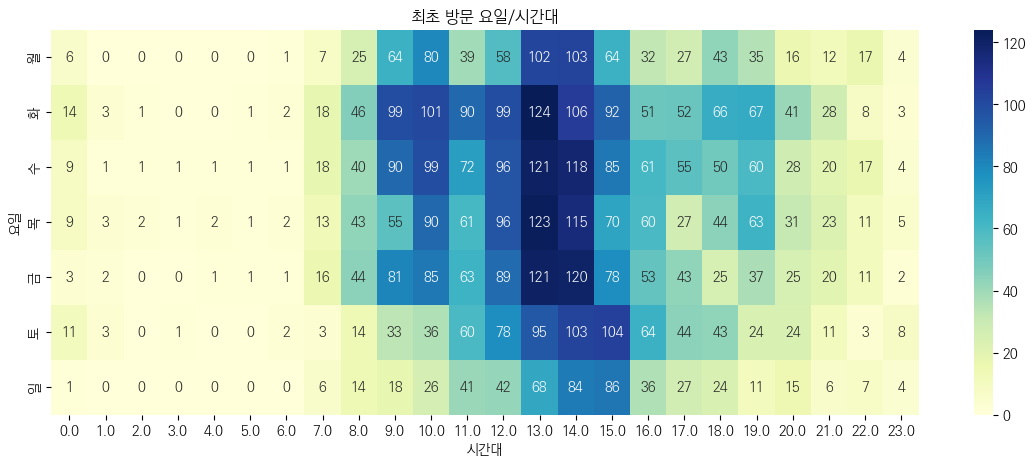

In [ ]:
# 요일/시간별 분포
weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
pivot.index = pivot.index.map(weekday_map)

plt.figure(figsize=(14,5))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='d')
plt.title('최초 방문 요일/시간대')
plt.xlabel('시간대')
plt.ylabel('요일')
plt.show()

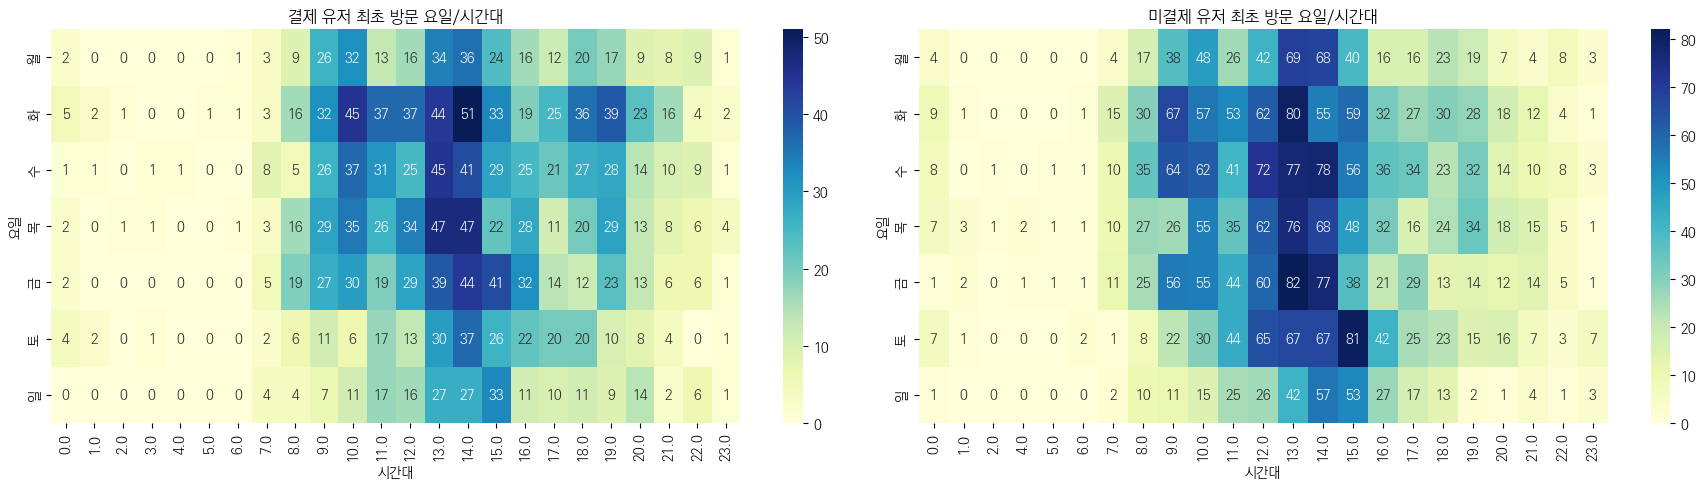

In [ ]:
# 결제 전환 유저 / 미전환 유저의 최초 방문 요일/시간대 비교
payment = dfs['trial_payment'].copy()
payment['is_payment'] = payment['is_payment'].astype(str)

# 결제 여부 join
tmp = first_visit_info.merge(payment[['user_uuid', 'is_payment']], on='user_uuid', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18,5))
for i, paid in enumerate(['1', '0']):
    subset = tmp[tmp['is_payment'] == paid]
    pivot = subset.pivot_table(index='weekday', columns='hour', values='user_uuid', aggfunc='count', fill_value=0)
    # 요일 인덱스 한글 매핑
    pivot.index = pivot.index.map(weekday_map)
    sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='d', ax=axes[i])
    axes[i].set_title(f"{'결제' if paid=='1' else '미결제'} 유저 최초 방문 요일/시간대")
    axes[i].set_xlabel('시간대')
    axes[i].set_ylabel('요일')
plt.tight_layout()
plt.show()

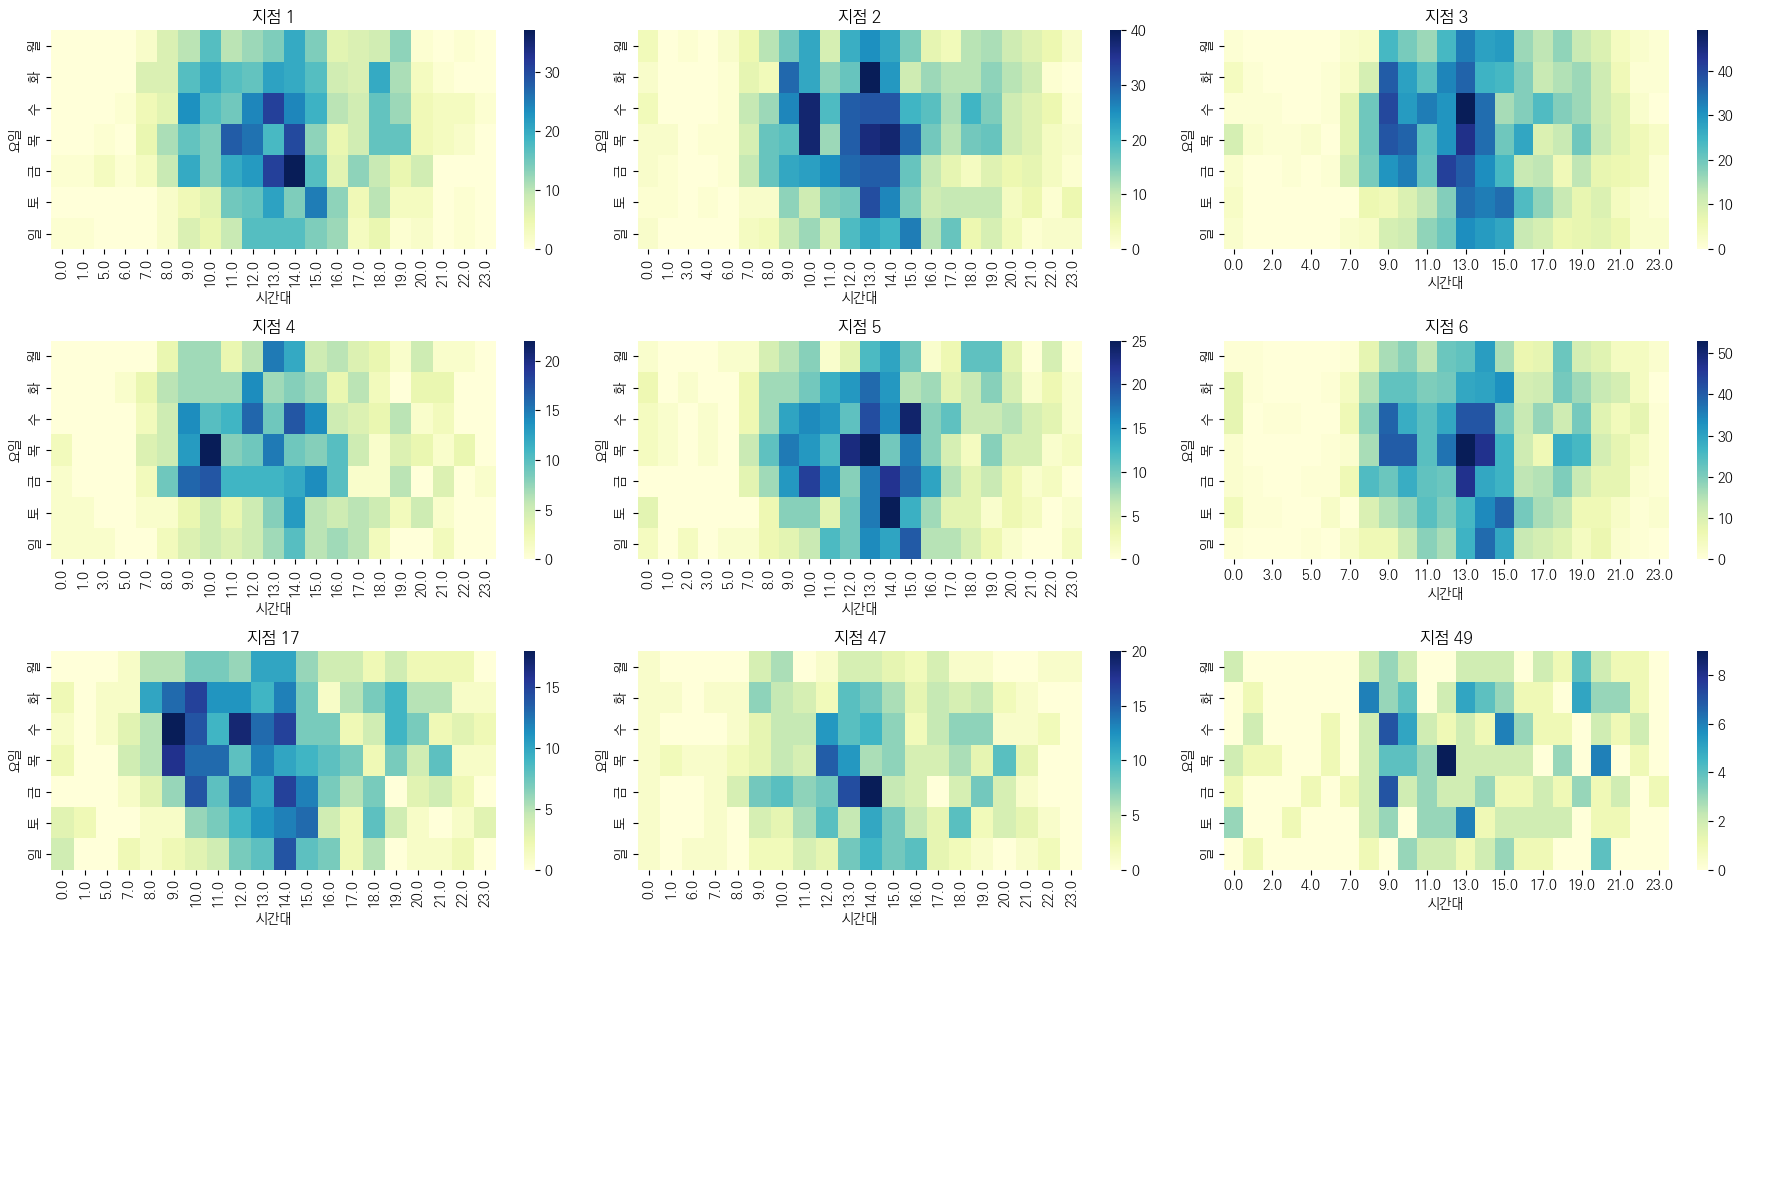

In [8]:
# 지점별 방문 요일/시간대 히트맵
visit = dfs['trial_visit_info'].copy()
visit['date'] = pd.to_datetime(visit['date'])
visit['weekday'] = visit['date'].dt.dayofweek
visit['hour'] = pd.to_datetime(visit['first_enter_time'], errors='coerce').dt.hour

site_ids = visit['site_id'].unique()
fig, axes = plt.subplots(len(site_ids)//3+1, 3, figsize=(18, 3*len(site_ids)//3+3))
axes = axes.flatten()
for i, site in enumerate(sorted(site_ids)):
    subset = visit[visit['site_id'] == site]
    pivot = subset.pivot_table(index='weekday', columns='hour', values='user_uuid', aggfunc='count', fill_value=0)
    # 요일 인덱스 한글 매핑
    pivot.index = pivot.index.map(weekday_map)
    sns.heatmap(pivot, cmap='YlGnBu', annot=False, ax=axes[i])
    axes[i].set_title(f'지점 {site}')
    axes[i].set_xlabel('시간대')
    axes[i].set_ylabel('요일')
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


In [17]:
# 지점별 총 방문자 수(유니크 유저)만 집계 및 시각화
import plotly.express as px

visit = dfs['trial_visit_info'].copy()
site_user = visit.groupby('site_id')['user_uuid'].nunique().reset_index().rename(columns={'user_uuid': 'unique_users'})
site_user['site_id'] = site_user['site_id'].astype(str)

fig = px.bar(
    site_user,
    x='site_id',
    y='unique_users',
    text='unique_users',
    color='unique_users',
    color_continuous_scale='viridis',
    title='지점별 총 방문자 수',
    width=700,
    height=600
)
fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title='지점 ID',
    yaxis_title='방문자 수',
    font=dict(size=14),
    plot_bgcolor='rgba(245,245,245,1)',
    xaxis=dict(type='category')
)
fig.show()


In [27]:
# 결제 여부별 주요 방문지점 분포
import plotly.express as px

fig = px.histogram(
    user_feat_final,
    x='preferred_site_id_enc',
    color='is_payment',
    barmode='group',
    text_auto=True,
    color_discrete_sequence=['#7ec8e3', '#2b7a78'],
    category_orders={'is_payment': [1, 0]}
)
fig.update_layout(
    title='결제 여부별 주요 방문지점 분포',
    xaxis_title='preferred_site_id_enc',
    yaxis_title='유저 수',
    legend_title='is_payment',
    template='plotly_white',
    plot_bgcolor='#eaf6fb',
    width=700,
    height=500
)
fig.show()

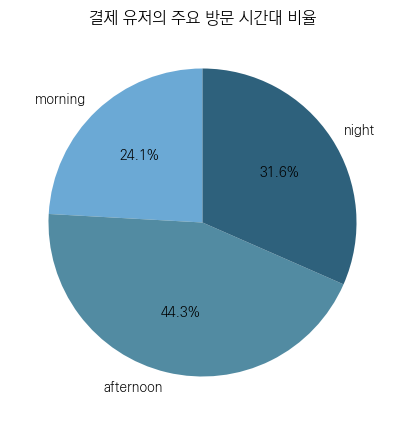

In [29]:
# 결제 유저의 주요 방문 시간대 비율 (pie chart)
pay_time = user_feat_final[user_feat_final['is_payment']==1][['morning','afternoon','night']].mean()
plt.figure(figsize=(5,5))
plt.pie(pay_time, labels=pay_time.index, autopct='%1.1f%%', startangle=90, colors=["#6BA9D5","#528BA2","#2E617C"])
plt.title('결제 유저의 주요 방문 시간대 비율')
plt.show()

# 모델링

## LightGBM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             classification_report)
from lightgbm import LGBMClassifier

In [ ]:
# 피쳐, 타겟 나누기
X = user_feat_final.drop(columns=['user_uuid', 'is_payment'])
y = user_feat_final[['is_payment']]

# training data와 test data로 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)

# 스케일링
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 모델 생성
lgb = LGBMClassifier()

# 모델 학습
lgb.fit(X_train_scaled, y_train)

# 데이터 예측
y_test_pred = lgb.predict(X_test_scaled)

# 예측 확률 구하기
y_test_pred_prob = lgb.predict_proba(X_test_scaled)[:,1]
y_test_pred_03 = (y_test_pred_prob >= 0.3).astype(int)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 1761, number of negative: 2757
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000420 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 647
[LightGBM] [Info] Number of data points in the train set: 4518, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.389774 -> initscore=-0.448261
[LightGBM] [Info] Start training from score -0.448261


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print('TRAIN Accuracy: ', round(lgb.score(X_train_scaled, y_train), 3))
print('TEST Accuracy: ', round(lgb.score(X_test_scaled, y_test), 3))
print('Accuracy: ', accuracy_score(y_test, y_test_pred_03))
print('Precision: ', precision_score(y_test, y_test_pred_03))
print('Recall: ', recall_score(y_test, y_test_pred_03))
print('F1 Score: ', f1_score(y_test, y_test_pred_03))
print('AUC: ', roc_auc_score(y_test, y_test_pred_prob))
print('Classification Report: ', classification_report(y_test, y_test_pred))

TRAIN Accuracy:  0.801
TEST Accuracy:  0.644
Accuracy:  0.5295288652952886
Precision:  0.43121149897330596
Recall:  0.7304347826086957
F1 Score:  0.5422853453841188
AUC:  0.6259927225228588
Classification Report:                precision    recall  f1-score   support

           0       0.67      0.83      0.74       932
           1       0.55      0.35      0.43       575

    accuracy                           0.64      1507
   macro avg       0.61      0.59      0.59      1507
weighted avg       0.63      0.64      0.62      1507



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# 속성 중요도

In [ ]:
# 속성 중요도 파악
importances = lgb.feature_importances_
importances

array([210, 114, 112, 749,  79,   9,  33, 125, 112,  86, 101, 249, 256,
       642,  10, 113], dtype=int32)

In [ ]:
# 피처 이름과 중요도를 함께 보기
feature_importance = pd.Series(lgb.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

avg_stay_time        749
stay_density         642
exit_count           256
entry_count          249
register_weekday     210
preferred_site_id    125
first_visit_delay    114
반경_500m_점포수          113
visit_days           112
afternoon            112
night                101
morning               86
visit_weekdays        79
site_count            33
is_big_site_user      10
visit_weekend          9
dtype: int32

In [ ]:
indices_sorted = np.argsort(importances)
importances[indices_sorted]

array([  9,  10,  33,  79,  86, 101, 112, 112, 113, 114, 125, 210, 249,
       256, 642, 749], dtype=int32)

/Users/bettertospeak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bettertospeak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bettertospeak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bettertospeak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bettertospeak/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170:

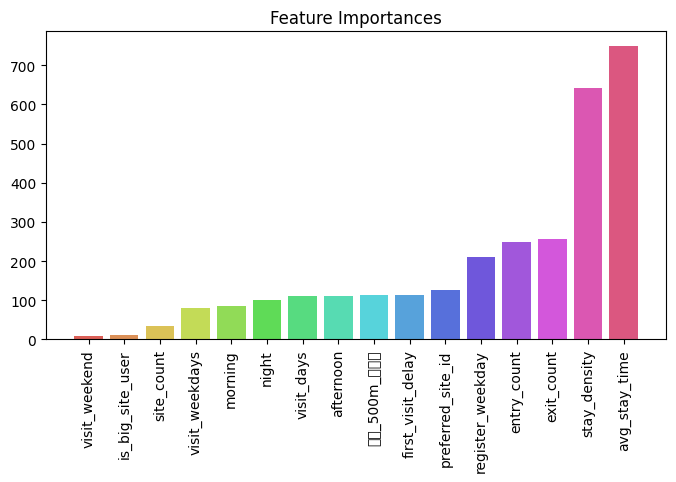

In [ ]:
# 속성 중요도 시각화
colors = sns.color_palette('hls',len(importances))

plt.figure(figsize=(8,4))
plt.bar(range(len(importances)), importances[indices_sorted], color=colors)
plt.title('Feature Importances')
plt.xticks(range(len(importances)), X.columns[indices_sorted], rotation=90)
plt.show()

# 비즈니스 액션 제안을 위한 추가 EDA

In [ ]:
# 원본 보존을 위한 복사
df = user_feat_final.copy()

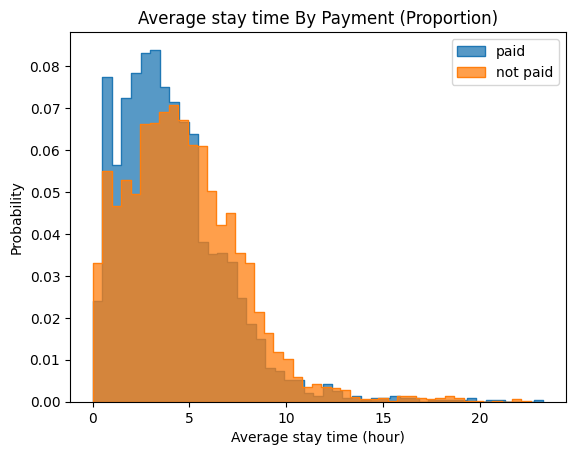

In [ ]:
# 비율 기준으로 히스토그램 그리기
df['avg_stay_hour'] = df['avg_stay_time'] / 3600

sns.histplot(data=df[df['is_payment'] == 1]['avg_stay_hour'],
             label='paid',
             fill=True,
             stat='probability',
             element='step')

sns.histplot(data=df[df['is_payment'] == 0]['avg_stay_hour'],
             label='not paid',
             fill=True,
             stat='probability',
             element='step')

plt.xlabel('Average stay time (hour)')
plt.title('Average stay time By Payment (Proportion)')
plt.legend()
plt.show()

In [ ]:
# 늦은 아침 ~ 한낮 오후까지 방문자수가 많은 양상을 보임
temp = trial_visit_info.copy()
temp['hour'] = temp['first_enter_time'].dt.hour
temp.groupby(['hour'])['user_uuid'].count().sort_values(ascending=False).head(10)

hour
13.0    1221
14.0    1178
12.0     936
15.0     899
10.0     869
9.0      827
11.0     726
16.0     531
18.0     495
19.0     465
Name: user_uuid, dtype: int64